## Impl directories to analyze

In [1]:
from pathlib import Path
from modular_main.settings import AGENT, MODEL
from typing import Literal
import os 

# Modes refer to the thing after underscore in implementations_XXX folder, see #settings 
MODES = ["noDesign", "auto", "human", "autoTest", "autoNoMetric"]   
PROBLEM = "circuit_eval"
TYPE: Literal["scb", "custom", "reference"] = "scb" 

if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "reference": 
    base = f"datasets/references/{PROBLEM}"
    dirs = sorted([os.path.join(base, name) for name in os.listdir(base)])

    # do further processing to isolate out the folder you want to analyze, see constants.py 
    dirs = [os.path.join(x, "httpie", "cli") for x in dirs]
    
    dirs = [Path(x) for x in dirs]

    # modes is "reference" (for showing on the graphs) 
    MODES = ["reference"]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")


# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_auto_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_human_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_autoTest_codex_gpt-5.6-luna'),
 PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_autoNoMetric_codex_gpt-5.6-luna')]

## Extract the relevant metrics
metrics_dpy is in the form of `[ [{}, {}, {}...], [{}, {},...] ]` one array for one workflow mode

In [2]:
import os 
from write_metrics.write_eval_metrics import get_eval_metrics

metrics = [] 
if TYPE in ["scb", "custom"]: 
    for mode_no, mode in enumerate(MODES): 
        # Obtain the checkpoint directories names of the problem
        # checkpoint_1, checkpoint_2, ... checkpoint_N
        checkpoint_dirs = []
        for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
            # only extract the top level iteration 
            checkpoint_dirs = dir 
            break 

        # remove directories that does not start with checkpoint_X
        checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
        checkpoint_dirs.sort() 

        mode_metrics = [] 

        # walk through each checkpoint 
        for i, checkpoint_name in enumerate(checkpoint_dirs): 
            impl_dir = dirs[mode_no] / checkpoint_name
            mode_metrics.append(
                get_eval_metrics(implementation_path=impl_dir) 
            )
        
        metrics.append(mode_metrics) 

elif TYPE == "reference": 
    # Directly use the dir as implementation path
    for dir in dirs: 
        metrics.append(
            get_eval_metrics(dir)
        )

        # Simulate one mode 
    metrics = [metrics] 
metrics


[GRAPH 1/6] Generating missing init.py
[GRAPH 2/6] Generating temp entrypoint file
[GRAPH 3/6] Generating dependency graph
[GRAPH 4/6] Converting the dependency graphs to JSON
[GRAPH 5/6] Generating visibility matrix


/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, n)
/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, n)


[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_158742_1787418115_119931/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 172	Number of packages: 1
	Number of classes: 14	Number of modules: 1
	number of methods/functions: 12
-T

/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, n)
/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, n)


[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_158871_1787418126_239318/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 219	Number of packages: 1
	Number of classes: 18	Number of modules: 1
	number of methods/functions: 13
-T

...

/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, n)
/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, n)


[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_7
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_159507_1787418179_502479/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 883	Number of packages: 1
	Number of classes: 31	Number of modules: 1
	number of methods/functions: 42
-T

/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, n)
/home/bernardmoy/modular-SWE/scripts/gen_visibility_matrix.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, n)


[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_8
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_159618_1787418190_494076/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis complete.
Preparing analysis summary ...
--Analysis summary--
	Total LOC analyzed: 1137	Number of packages: 1
	Number of classes: 31	Number of modules: 1
	number of methods/functions: 56
-

[[{'implementation_path': PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1'),
   'lloc': 256,
   'loc': 214,
   'lloc_per_function': 21.333,
   'lloc_per_module': 256.0,
   'function_max_loc': 47,
   'modules_max_lloc': 256,
   'comments_percentage': 1.869,
   'cc_per_function': 5.417,
   'high_cc_functions_count': 2,
   'function_max_cc': 22,
   'weighted_mi': 22.085,
   'propagation_cost': 1,
   'impact_size': 0,
   'has_cycles': False,
   'number_of_modules': 1,
   'number_of_functions': 12,
   'nopm_per_class': 0.667,
   'class_max_nopm': 6,
   'duplicated_lines': 0.0,
   'duplicated_tokens': 0.0},
  {'implementation_path': PosixPath('datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2'),
   'lloc': 345,
   'loc': 257,
   'lloc_per_function': 26.538,
   'lloc_per_module': 345.0,
   'function_max_loc': 51,
   'modules_max_lloc': 345,
   'comments_percentage': 0.3

## Reusable plot function

In [3]:
from matplotlib import pyplot as plt 

def plot(metrics, metrics_names): 
    N = len(metrics_names) 
    figsize = (5*N, 5)
    fig, axes = plt.subplots(1, N, figsize=figsize)

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    for i, metric in enumerate(metrics_names): 
        data = [[x[metric] for x in entry] for entry in metrics]
        ax = axes[i]
        for j, entry in enumerate(data):
            x = range(1, len(entry) + 1) 
            y = entry
            ax.plot(x, y, label=MODES[j])
        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Change coupling metrics

datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1->datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2: ['circopt.py']
datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2->datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3: ['circopt.py']
datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3->datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4: ['circopt.py']
datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4->datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_5: ['circopt.py']
datasets/slopCodeBench/scb-problems/circuit_eval/implementations_noDesign_codex_gpt-

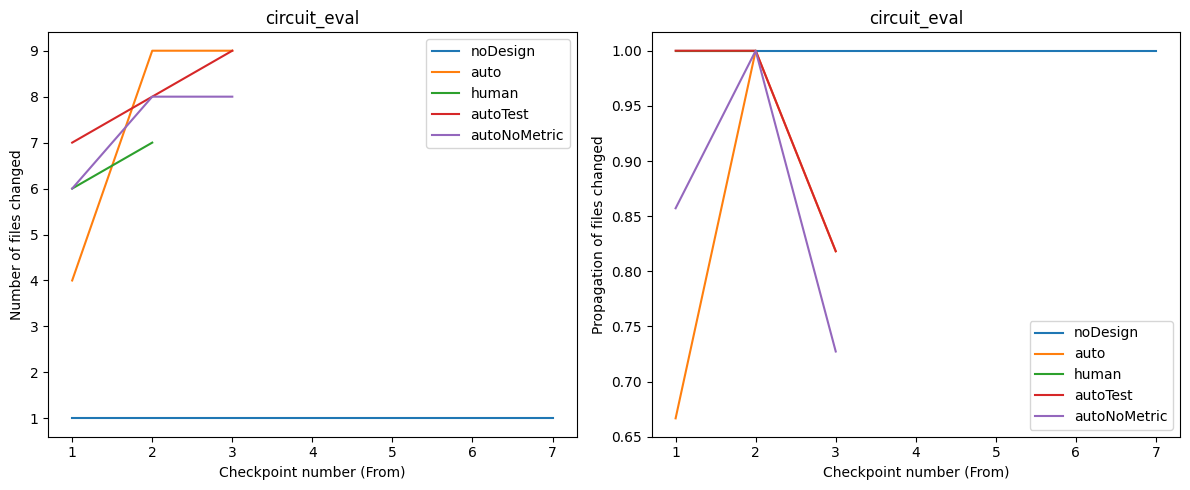

In [4]:
import os 
from metrics.change_coupling.overall_metrics import get_added_files, get_changed_files, get_deleted_files, get_all_modules, get_change_coupling

# data is in the form of [[c1, c2, ...], [c1, c2, ...]]
change_numbers = [] 
change_proportions = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    cur_numbers = [] 
    cur_proportions = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        changed = get_changed_files(prev_impl_dir, impl_dir)
        total = get_all_modules(prev_impl_dir)
        print(f"{prev_impl_dir}->{impl_dir}: {get_changed_files(prev_impl_dir, impl_dir)}")

        cur_numbers.append(len(changed)) 
        cur_proportions.append(len(changed) / len(total))

    change_numbers.append(cur_numbers) 
    change_proportions.append(cur_proportions) 

    # print the change coupling metric 
    impl_dirs = [dirs[mode_no] / x for x in checkpoint_dirs]
    print(impl_dirs)
    print(get_change_coupling(impl_dirs))

# plot 
from matplotlib import pyplot as plt 
from matplotlib.ticker import MaxNLocator

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, entry in enumerate(change_numbers):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number (From)")
ax1.set_ylabel("Number of files changed")
ax1.set_title(PROBLEM)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.legend()

for i, entry in enumerate(change_proportions):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number (From)")
ax2.set_ylabel("Propagation of files changed")
ax2.set_title(PROBLEM)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend()

plt.tight_layout()
plt.show()

## Logical lines of code

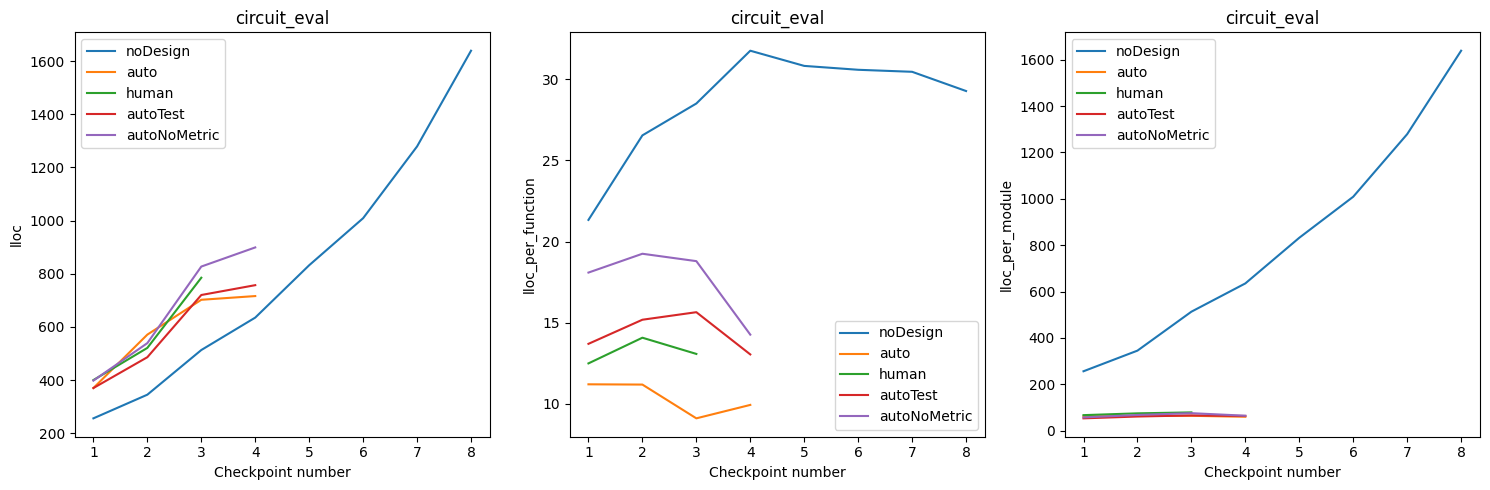

In [5]:
plot(metrics, ["lloc", "lloc_per_function", "lloc_per_module"])

## Functions with high CC / LOC

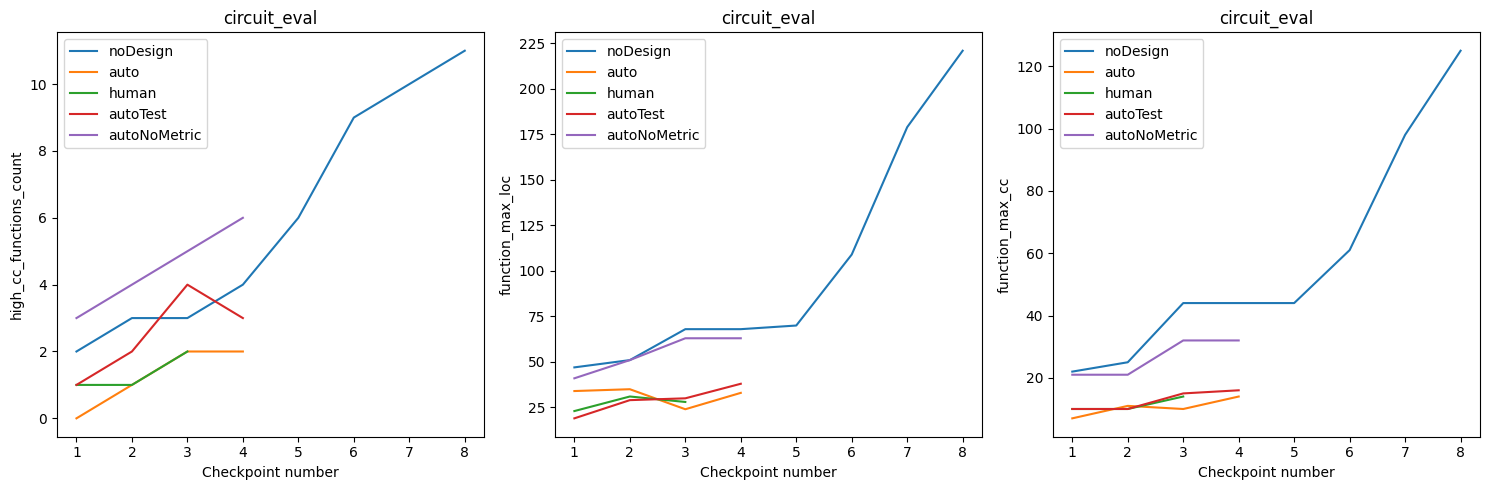

In [6]:
plot(metrics, ["high_cc_functions_count", "function_max_loc", "function_max_cc"])

## Maintainability index (Weighted)

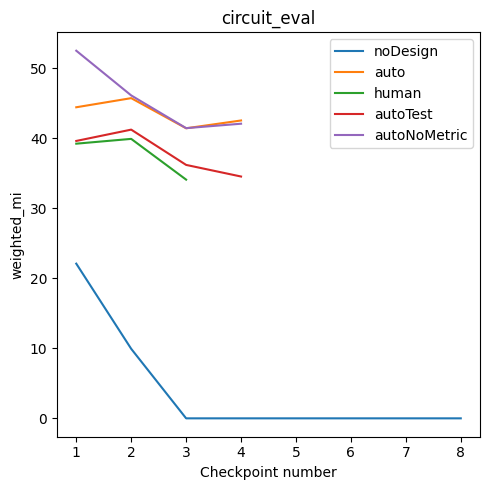

In [7]:
plot(metrics, ["weighted_mi"])

## Duplicated lines and tokens percentage

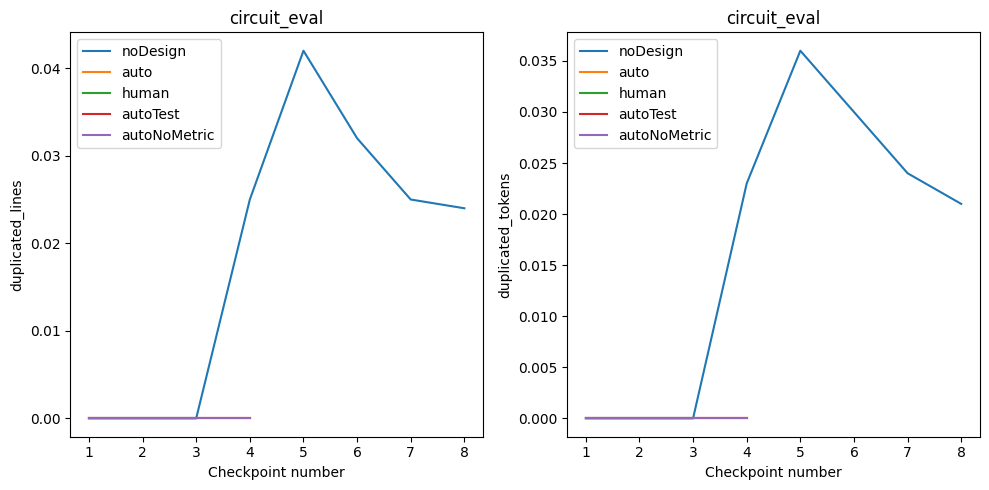

In [8]:
plot(metrics, ["duplicated_lines", "duplicated_tokens"])

## Whether graph has cycles

In [9]:
for i, entry in enumerate(metrics): 
    print(f"{MODES[i]}: {[x["has_cycles"] for x in entry]}")

noDesign: [False, False, False, False, False, False, False, False]
auto: [False, False, False, False]
human: [False, False, False]
autoTest: [False, False, False, False]
autoNoMetric: [False, False, False, False]


## NOPM per class

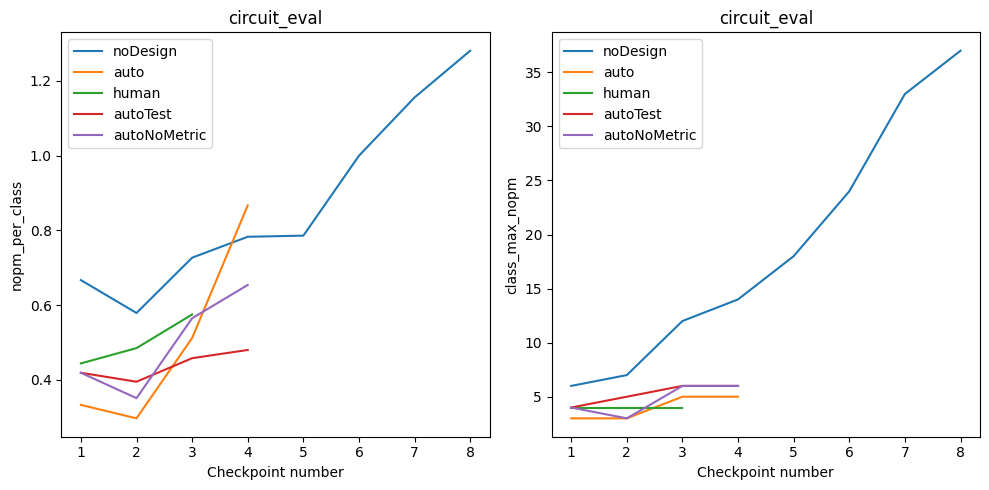

In [10]:
plot(metrics, ["nopm_per_class", "class_max_nopm"])

## Propagation cost, N and impact size

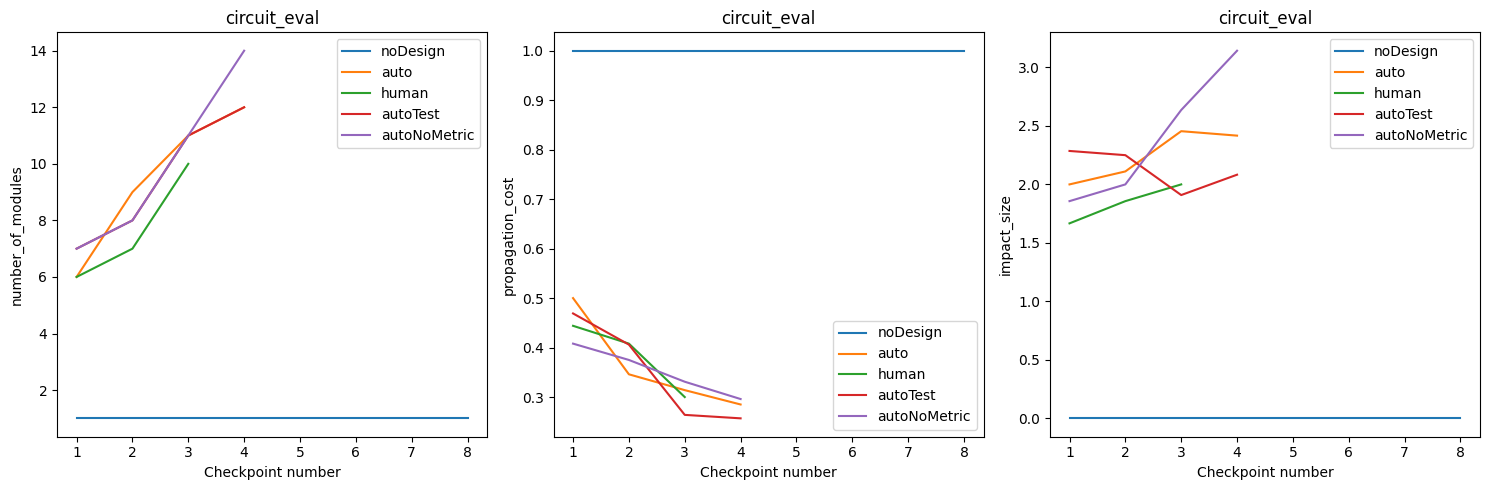

In [11]:
plot(metrics, ["number_of_modules", "propagation_cost", "impact_size"])

## Spider diagrams (test) 

## 

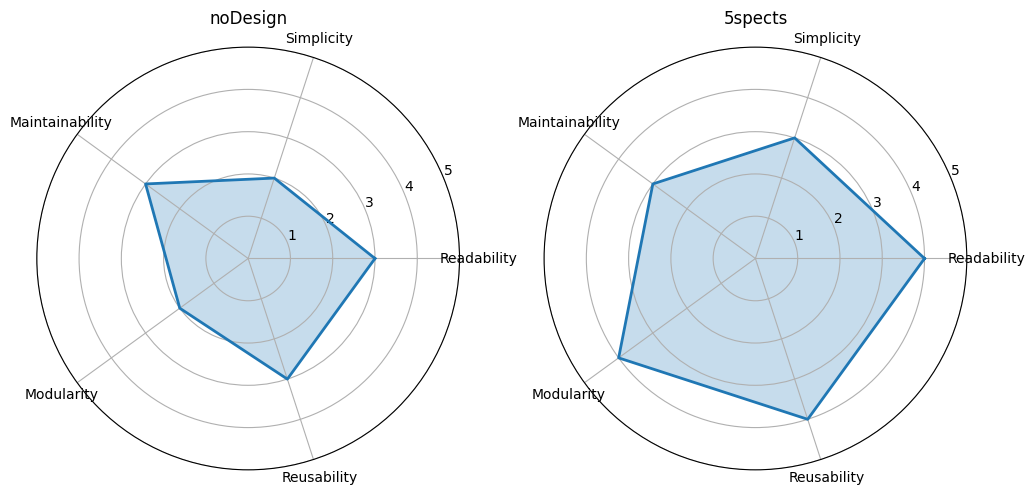

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["Readability", "Simplicity", "Maintainability", "Modularity", "Reusability"]
values_noDesign = [3,2,3,2,3]
values_5aspects = [4,3,3,4,4]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

# Values also need to loop back to the first point
# (Append the first value to the end) 
values_noDesign += values_noDesign[:1]
values_5aspects += values_5aspects[:1]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 6), subplot_kw=dict(polar=True))

# Draw the outline and fill
ax1.plot(angles, values_noDesign, linewidth=2, linestyle='solid')
ax1.fill(angles, values_noDesign, alpha=0.25)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])

ax1.set_title("noDesign")

# Draw the outline and fill
ax2.plot(angles, values_5aspects, linewidth=2, linestyle='solid')
ax2.fill(angles, values_5aspects, alpha=0.25)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax2.set_ylim(0, 5)
ax2.set_yticks([1, 2, 3, 4, 5])

ax2.set_title("5spects")

plt.show()